### Trapezoidal Rule

The **Trapezoidal Rule** approximates the definite integral of a function by dividing the interval \\([a,b]\\) into \\(n\\) subintervals and approximating the area under the curve with trapezoids:
$$
\int_a^b f(x)\,dx \approx \frac{h}{2}\left[f(x_0) + 2\sum_{i=1}^{n-1}f(x_i) + f(x_n)\right], \qquad h = \frac{b-a}{n}
$$

The trapezoidal rule is exact for linear functions and has error \\(O(h^2)\\); accuracy improves as the number of subintervals \\(n\\) increases.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return np.sin(x)


In [3]:
def trapezoidal_table(f, a, b, n_values):
    print(f"{'n':>4} {'h':>12} {'integral':>14}")
    print("-" * 35)

    results = []
    for n in n_values:
        h = (b - a) / n
        x = np.linspace(a, b, n + 1)
        y = f(x)
        integral = h * (y[0] / 2 + y[-1] / 2 + np.sum(y[1:-1]))
        results.append(integral)
        print(f"{n:4d} {h:12.6f} {integral:14.6f}")

    return results


In [4]:
a, b = 0, np.pi
n_values = [2, 4, 8, 16, 32]
results = trapezoidal_table(f, a, b, n_values)

integral_final = results[-1]
print(f"\nTrapezoidal estimate (n={n_values[-1]}) = {integral_final:.6f}")
print(f"Exact value of integral = {-(np.cos(b) - np.cos(a)):.6f}")


   n            h       integral
-----------------------------------
   2     1.570796       1.570796
   4     0.785398       1.896119
   8     0.392699       1.974232
  16     0.196350       1.993570
  32     0.098175       1.998393

Trapezoidal estimate (n=32) = 1.998393
Exact value of integral = 2.000000


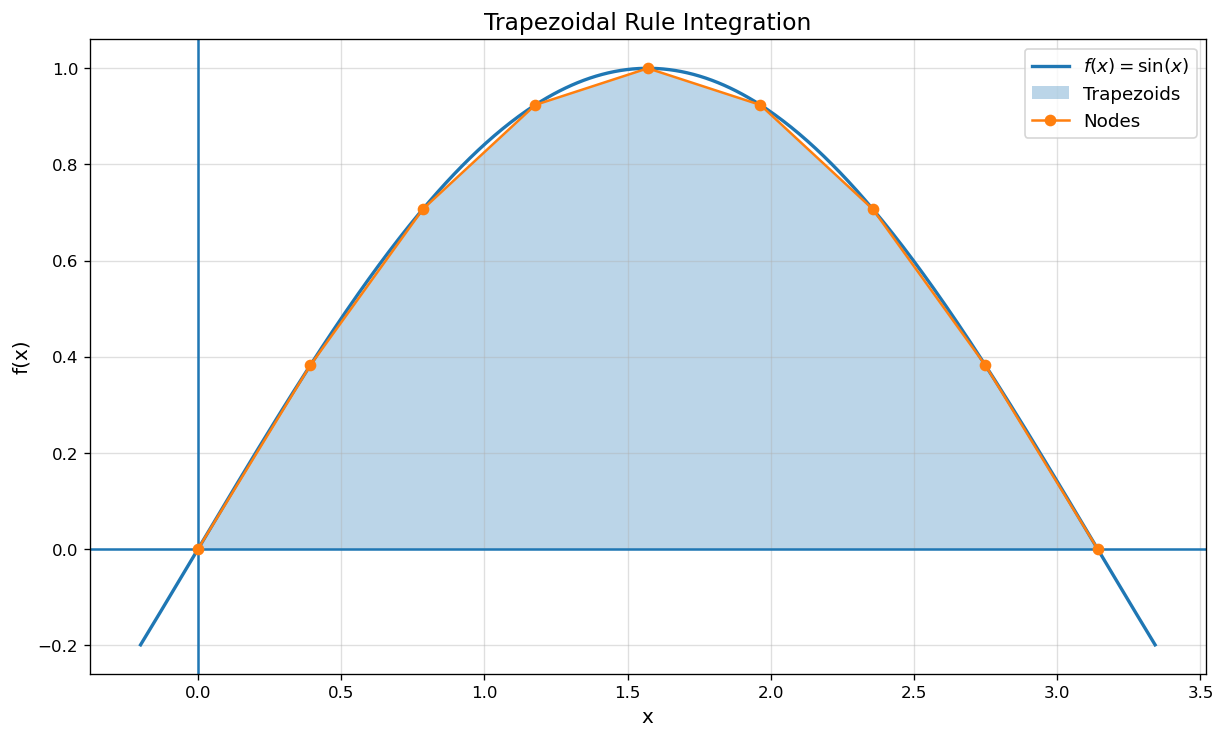

In [5]:
plt.figure(figsize=(12, 7), dpi=120)

# Axes lines (Desmos-style)
plt.axhline(0)
plt.axvline(0)

n = 8
h = (b - a) / n
x_nodes = np.linspace(a, b, n + 1)
y_nodes = f(x_nodes)

x = np.linspace(a - 0.2, b + 0.2, 500)
y = f(x)

plt.plot(x, y, linewidth=2, label=r"$f(x)=\sin(x)$")
plt.fill_between(x_nodes, y_nodes, alpha=0.3, step=None, label="Trapezoids")
plt.plot(x_nodes, y_nodes, 'o-', markersize=6, label="Nodes")

plt.grid(True, alpha=0.4)
plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)
plt.title("Trapezoidal Rule Integration", fontsize=14)

plt.legend(fontsize=11)
plt.show()
